In [1]:
# Importing Required librareis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [2]:
# Importing the data
df = pd.read_csv("irrigation_prediction.csv")
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [3]:
df.shape

(10000, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

In [5]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [6]:
num_df = df.select_dtypes(include = 'number')
num_df.columns

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
      dtype='object')

In [7]:
# sns.pairplot(df, hue = 'Irrigation_Need', palette = 'rainbow')
# plt.show()

In [8]:
obj_df = df.select_dtypes(include = 'O')
print(obj_df.shape)
obj_df.head()

(10000, 9)


,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region,Irrigation_Need
0,Clay,Wheat,Vegetative,Rabi,Rainfed,Reservoir,Yes,South,Low
1,Silt,Maize,Flowering,Zaid,Canal,Groundwater,Yes,Central,Medium
2,Sandy,Cotton,Harvest,Rabi,Drip,Reservoir,Yes,South,Low
3,Clay,Wheat,Sowing,Kharif,Canal,Reservoir,Yes,North,Medium
4,Clay,Cotton,Sowing,Zaid,Canal,River,No,South,Medium


In [9]:
cat_cols = obj_df.columns.tolist()
print(cat_cols)

['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']


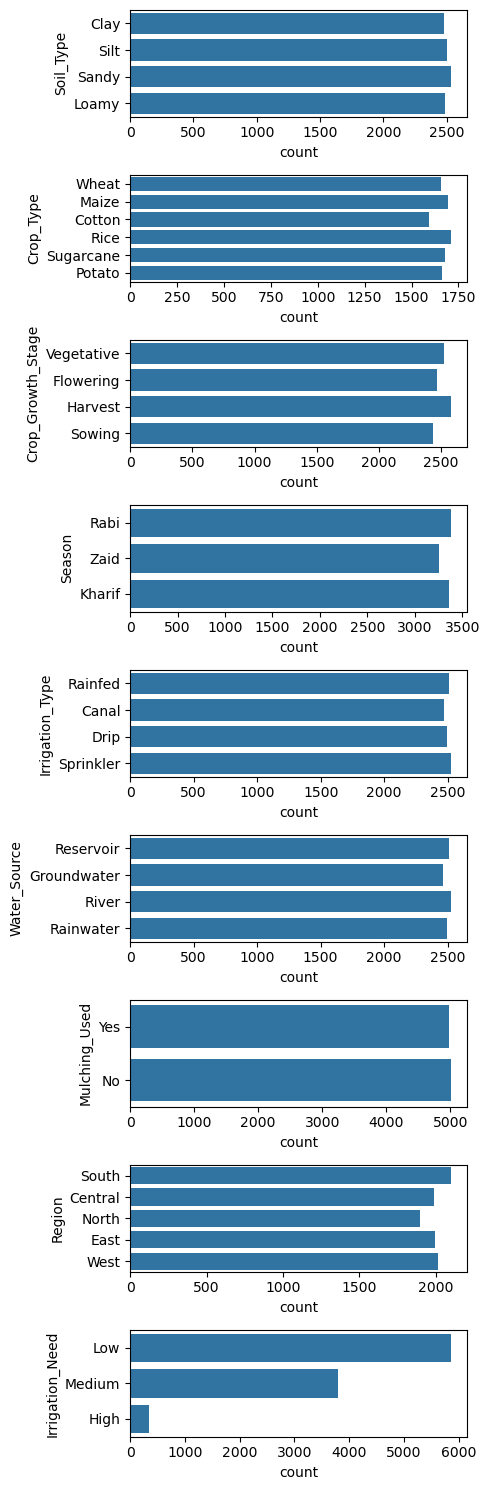

In [10]:
fig, ax = plt.subplots(9,1, figsize = (5,15))
for i in cat_cols:
    sns.countplot(df[i],ax = ax[cat_cols.index(i)])
    plt.tight_layout()
plt.show()

In [11]:
X = df.drop("Irrigation_Need", axis = 1)
y = df['Irrigation_Need']

In [12]:
X.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South


In [13]:
y.head()

0       Low
1    Medium
2       Low
3    Medium
4    Medium
Name: Irrigation_Need, dtype: object

In [14]:
print(cat_cols)

['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']


In [15]:
encoder = LabelEncoder()
for col in cat_cols[:-1]:
    X[col] = encoder.fit_transform(X[col])

In [16]:
X.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,0,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,5,3,1,2,2,4.73,1,1.98,3
1,3,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,1,0,2,0,0,12.22,1,33.56,0
2,2,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,0,1,1,1,2,5.52,1,34.62,3
3,0,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,5,2,0,0,2,1.43,1,84.03,2
4,0,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,0,2,2,0,3,2.52,0,60.86,3


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 11, test_size = 0.3)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7000, 19) (3000, 19) (7000,) (3000,)


In [62]:
dtc = DecisionTreeClassifier(criterion='entropy',splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
y_pred = dtc.predict(X_test)
print(y_pred[90:100])

In [ ]:
y_test[90:100]

In [68]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

        High       0.99      0.97      0.98        99
         Low       1.00      1.00      1.00      1781
      Medium       0.99      1.00      0.99      1120

    accuracy                           1.00      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       1.00      1.00      1.00      3000

